# Mean-Variance Portfolio Optimization with cuOpt

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Optional Notebook</h4>
This is an <strong>optional</strong> notebook highlighting that <strong>NVIDIA cuOpt 26.02</strong> now supports solving <strong>Quadratic Programs (QP)</strong>, enabling standard <strong>Markowitz Mean-Variance</strong> portfolio optimization directly on the GPU.

The main course notebooks focus on <strong>CVaR optimization</strong> (a linear program). This notebook shows how the same framework extends to QP problems with a quadratic objective <code>w'Σw</code>.
</div>


## Table of Contents

1. [Setup](#setup) — GPU check & imports
2. [Mathematical Formulation](#introduction) — The Markowitz QP
3. [Solve with cuOpt](#solve) — Data, parameters & GPU optimization
4. [Results](#analyze) — Portfolio visualization & statistics


---

<a id='setup'></a>
## 1. Setup


In [1]:
!nvidia-smi

Fri Mar 13 18:37:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100                    On  |   00000000:6B:00.0 Off |                    0 |
| N/A   47C    P0            120W /  700W |    2316MiB /  97871MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os

import numpy as np

from cufolio import mean_variance_optimizer, utils
from cufolio.mean_variance_parameters import MeanVarianceParameters
from cufolio.settings import ApiSettings, ReturnsComputeSettings


---

<a id='introduction'></a>
## 2. Mathematical Formulation

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-Variance (Markowitz) Optimization</h4>
Mean-Variance optimization, introduced by Harry Markowitz in 1952, is the foundation of Modern Portfolio Theory. The objective trades off expected return against portfolio variance:

\begin{align*}
\text{maximize } \quad &\mu^\top w - \lambda_{\text{risk}} \cdot w^\top \Sigma w\\
\text{subject to} \quad 
& \sum_i w_i + c = 1 \quad \text{(self-financing)}\\
& w_i^{\text{min}} \leq w_i \leq w_i^{\text{max}}, \forall i \quad \text{(concentration)}\\
& c^{\text{min}} \leq c \leq c^{\text{max}} \quad \text{(cash)}\\
& L = \|w\|_1 \leq L^{\text{limit}} \quad \text{(leverage)}\\
& T = \|w - w_{\text{prev}}\|_1 \leq T^{\text{limit}} \quad \text{(turnover)}
\end{align*}

This is a **Quadratic Program (QP)** due to the $w^\top \Sigma w$ term. cuOpt 26.02 introduces QP support via a GPU-accelerated barrier solver.
</div>


---

<a id='solve'></a>
## 3. Solve with cuOpt

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 End-to-End: Data → Parameters → GPU Solve</h4>
We load S&P 500 price data, compute log-returns, define portfolio constraints, and solve the QP on the GPU using cuOpt.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>


In [3]:
dataset_name = "sp500"
data_path = f"../data/stock_data/{dataset_name}.csv"

if not os.path.exists(data_path):
    utils.download_data(data_path)

returns_dict = utils.calculate_returns(
    data_path,
    {"name": "recent", "range": ("2022-01-01", "2024-01-01")},
    ReturnsComputeSettings(return_type="LOG", freq=1),
)

print(f"Assets: {len(returns_dict['tickers'])}  |  "
      f"Observations: {len(returns_dict['returns'])}  |  "
      f"Covariance: {returns_dict['covariance'].shape}")


Assets: 392  |  Observations: 500  |  Covariance: (392, 392)


In [11]:
mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},
    w_max={"NVDA": 0.6, "others": 0.4},
    c_min=0.0,
    c_max=0.2,
    L_tar=1.6,
    risk_aversion=1.0,
)


In [12]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cuopt_python"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"time_limit": 60}
)


cuOpt MEAN-VARIANCE (QP) PROBLEM SETUP COMPLETED
Variables: 392 weights + 1 cash + 784 leverage aux
Covariance matrix: 392x392
Linear terms: 392
Problem Type: QP (Quadratic Programming)
Setting parameter time_limit to 6.000000e+01
cuOpt version: 26.2.0, git hash: f73da24d, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Silver 4314 CPU @ 2.40GHz, threads (physical/logical): 16/32, RAM: 87.50 GiB
CUDA 13.1, device: NVIDIA H100 (ID 0), VRAM: 95.08 GiB
CUDA device UUID: 54ffffff9bffffffcd68-ffffffa56c-68ff

Problem has a quadratic objective. Using Barrier.
Solving a problem with 394 constraints, 1177 variables (0 integers), and 2353 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party presolve is disabled, skipping
Objective offset

In [13]:
mean_variance_problem._print_cuopt_timing(mean_variance_problem.cuopt_timing_dict)
gpu_results


cuOpt SETUP TIMING BREAKDOWN
----------------------------------------
Create Problem           : 0.000011s (0.1%)
Add Weight Vars          : 0.000392s (2.8%)
Add Cash Var             : 0.000002s (0.0%)
Add Aux Vars             : 0.000720s (5.2%)
Budget Constraint        : 0.000048s (0.3%)
Decomp Constraints       : 0.000711s (5.1%)
Leverage Constraint      : 0.000084s (0.6%)
Turnover Constraints     : 0.000000s (0.0%)
Group Constraints        : 0.000000s (0.0%)
Build Quad Matrix        : 0.010286s (74.1%)
Build Linear Expr        : 0.000059s (0.4%)
Set Objective            : 0.001564s (11.3%)
----------------------------------------
Total Setup Time         : 0.013877s (100.0%)



regime          recent
solver           cuOpt
solve time    0.176377
return        0.002914
variance      0.000235
obj          -0.002892
dtype: object

---

<a id='analyze'></a>
## 4. Results


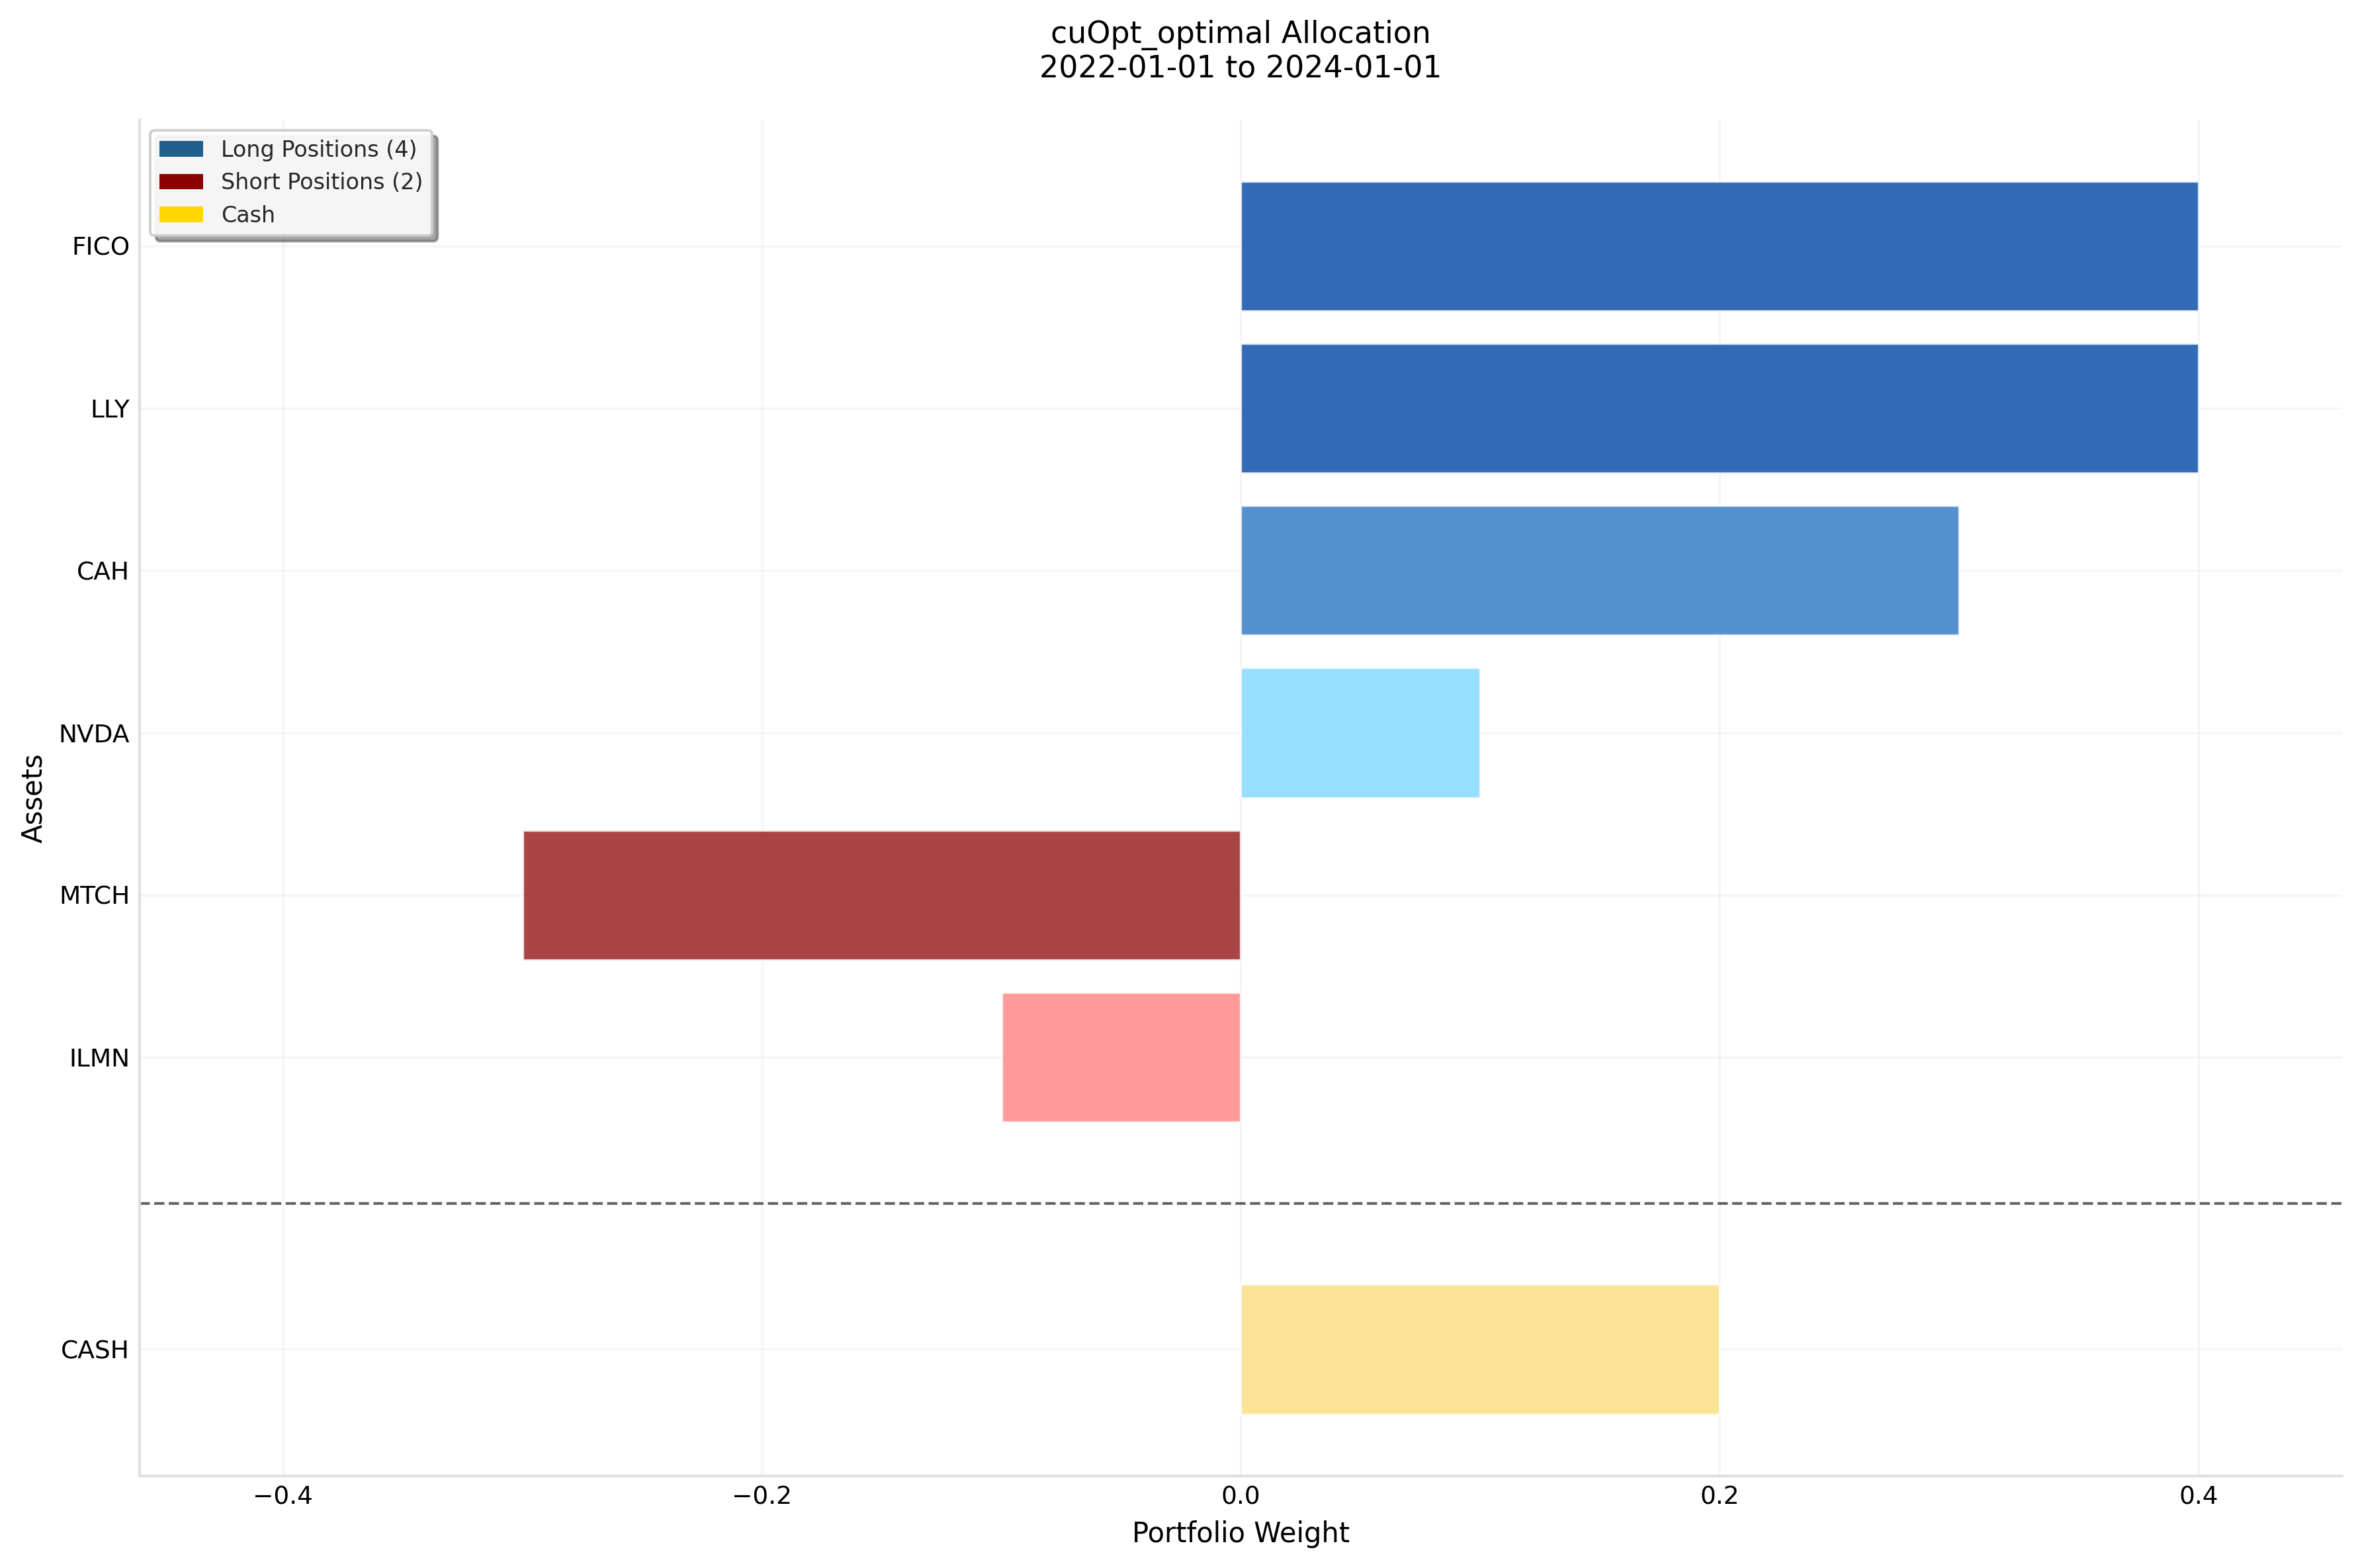

In [14]:
ax = gpu_portfolio.plot_portfolio(show_plot=True, min_percentage=1)


In [15]:
weights = gpu_portfolio.weights

expected_return = np.dot(returns_dict["mean"], weights)
portfolio_variance = weights @ returns_dict["covariance"] @ weights
portfolio_std = np.sqrt(portfolio_variance)
sharpe_ratio = expected_return / portfolio_std if portfolio_std > 0 else 0

print("Portfolio Statistics:")
print(f"  Expected Return: {expected_return:.4%}")
print(f"  Volatility (Std): {portfolio_std:.4%}")
print(f"  Variance: {portfolio_variance:.6f}")
print(f"  Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"  Cash Allocation: {gpu_portfolio.cash:.2%}")
print(f"  Leverage: {np.sum(np.abs(weights)):.4f}")
print(f"  Number of positions: {np.sum(np.abs(weights) > 0.001)}")


Portfolio Statistics:
  Expected Return: 0.2914%
  Volatility (Std): 1.5327%
  Variance: 0.000235
  Sharpe Ratio: 0.1901
  Cash Allocation: 20.00%
  Leverage: 1.6000
  Number of positions: 6


---

## Summary

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">✅ Key Takeaway</h4>
<strong>cuOpt 26.02</strong> adds QP support, enabling GPU-accelerated Markowitz Mean-Variance optimization alongside the existing LP-based CVaR solver. The same cuFOLIO framework handles both problem types — simply choose the appropriate optimizer class.

### Mean-Variance vs CVaR

| Aspect | Mean-Variance | CVaR |
|--------|---------------|------|
| Risk Measure | Variance (symmetric) | Tail risk (asymmetric) |
| Problem Type | QP (Quadratic) | LP (Linear) |
| Data Needed | Mean + Covariance | Scenarios |
| Distribution | Assumes normal | Distribution-free |

</div>
